# Notebook 4 - Ejecucion y costes

N4 transforma la cartera objetivo de N3 en resultados invertibles. El motor recorre el calendario dia a dia y ejecuta asignacion inicial, rebalanceos mensuales y salidas forzosas con trazabilidad completa de cada orden.

**Reglas del enunciado que gobiernan N4:**
- Venta de salida en rebalanceo: OPEN del dia de rebalanceo.
- Compra de entrada en rebalanceo: CLOSE del mismo dia.
- Coste por orden ejecutada: `max(0.23% * nocional, 23 USD)`.
- Si un activo sale del indice/mercado: venta al CLOSE del dia del evento.

**Politicas operativas declaradas:**
- `exit_without_open_policy = "strict_open"`: si falta OPEN en salida de rebalanceo, se registra `no_fill_open_missing` y no se inventa precio.
- `underfilled_portfolio_policy = "cash_only"`: si no se llega a 20 por caja o ejecutabilidad, la diferencia queda en liquidez.

**Artefactos que produce N4 (minimo necesario + auditoria):**

| Artefacto | Descripcion | Consumido por |
|---|---|---|
| `n4_orders_log.csv` | Registro de ordenes ejecutadas/no ejecutadas y su causa | N5, auditoria |
| `n4_portfolio_daily.csv` | Equity, caja y valor de mercado diarios | N5 |
| `n4_rebalance_summary.csv` | Resumen agregado por fecha de rebalanceo | N5 |
| `n4_rebalance_operational_summary.csv` | Tabla mensual de cobertura, no-fills y posiciones finales | N5, auditoria |
| `n4_cost_summary.csv` | Rentabilidad y desglose de costes | N5 |
| `n4_checks.csv` | Validaciones de cumplimiento e integridad | N5, auditoria |
| `n4_execution_coverage.csv` | Cobertura seleccion (N3) vs ejecutabilidad (N2) por fecha | Auditoria |

---

## 1. Configuración

Parámetros de ejecución, rutas de artefactos de N1/N2/N3, constantes de costes y funciones auxiliares.

In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

# --- Entradas ---
N1_RUNTIME = "data/processed/n1_runtime_params.csv"
# Asignación de 'N2_EXEC'
N2_EXEC = "data/processed/n2_execution_prices.parquet"
# Asignación de 'N3_SELECTED'
N3_SELECTED = "data/processed/n3_selected_assets.csv"
# Asignación de 'N3_INITIAL'
N3_INITIAL = "data/processed/n3_initial_allocation.csv"
CANONICAL = "data/processed/sp500_canonical.parquet"

# --- Salidas principales ---
OUT_ORDERS = "data/processed/n4_orders_log.csv"
# Ruta de salida: OUT_DAILY
OUT_DAILY = "data/processed/n4_portfolio_daily.csv"
# Ruta de salida: OUT_REBALANCE
OUT_REBALANCE = "data/processed/n4_rebalance_summary.csv"
# Ruta de salida: OUT_REBALANCE_OPS
OUT_REBALANCE_OPS = "data/processed/n4_rebalance_operational_summary.csv"
# Ruta de salida: OUT_COSTS
OUT_COSTS = "data/processed/n4_cost_summary.csv"
# Ruta de salida: OUT_CHECKS
OUT_CHECKS = "data/processed/n4_checks.csv"
# Ruta de salida: OUT_EXEC_COVERAGE
OUT_EXEC_COVERAGE = "data/processed/n4_execution_coverage.csv"

# --- Parametros operativos ---
TOP_N = 20
# Asignación de 'TARGET_WEIGHT'
TARGET_WEIGHT = 0.05

EXIT_WITHOUT_OPEN_POLICY = "strict_open"  # strict_open | proxy_fallback
# Asignación de 'UNDERFILLED_PORTFOLIO_POLICY'
UNDERFILLED_PORTFOLIO_POLICY = "cash_only"  # cash_only
# Asignación de 'MAX_EXECUTION_MISSING_RATIO'
MAX_EXECUTION_MISSING_RATIO = 0.20


# Control fail-fast: aborta si la condición crítica se incumple
def fail_if(condition, message):
    if condition:
        raise ValueError(message)


# Inicialización del contenedor para acumular resultados
checks = []


# Registro de validación con resultado PASS/FAIL para auditoría
def check(name, passed, details, critical=True):
    # Acumulación de resultado parcial
    checks.append(
        {
            "check": name,
            "passed": bool(passed),
            "critical": bool(critical),
            "details": str(details),
        }
    )
    # Control fail-fast: aborta si la condición crítica se incumple
    fail_if(critical and (not passed), f"[{name}] {details}")


# Definición de la función 'to_float'
def to_float(value, default):
    try:
        # Conversión de tipo escalar
        return float(value)
    except Exception:
        return float(default)


# Definición de la función 'calc_fee'
def calc_fee(notional, fee_rate, fee_min):
    return float(max(abs(notional) * fee_rate, fee_min))


# Salida informativa de seguimiento
print("Configuracion lista.")
# Diagnóstico con trazabilidad del resultado
print(f"  Politica OPEN faltante: {EXIT_WITHOUT_OPEN_POLICY}")
# Diagnóstico con trazabilidad del resultado
print(f"  Politica cartera incompleta: {UNDERFILLED_PORTFOLIO_POLICY}")



Configuracion lista.
  Politica OPEN faltante: strict_open
  Politica cartera incompleta: cash_only


---

## 2. Carga y validacion de inputs

Se cargan los artefactos de N1, N2 y N3 necesarios para la simulacion: parametros de ejecucion, precios de ejecucion con flag de ejecutabilidad, seleccion mensual de 20 activos y dataset canonico para valoracion diaria y eventos de salida del indice.

Antes de ejecutar el motor se validan tres bloques:
- Contrato de cartera objetivo (20 activos, ranks 1..20 y peso 5% por fila).
- Cobertura seleccion -> ejecutabilidad por fecha.
- Coherencia temporal (asignacion inicial y calendario operativo).

In [ ]:
# Carga de artefactos
required_paths = [N1_RUNTIME, N2_EXEC, N3_SELECTED, N3_INITIAL, CANONICAL]
# Iteración sobre required_paths
for path in required_paths:
    # Control fail-fast: aborta si la condición crítica se incumple
    fail_if(not Path(path).is_file(), f"No existe: {path}")

# Lectura del fichero CSV de configuración/parámetros
runtime_params = dict(zip(*pd.read_csv(N1_RUNTIME)[["parameter", "value"]].values.T))
# Conversión a escalar float: initial_capital
initial_capital = to_float(runtime_params.get("initial_capital", "250000"), 250000.0)
# Conversión a escalar float: fee_rate
fee_rate = to_float(runtime_params.get("transaction_fee_rate", "0.0023"), 0.0023)
# Conversión a escalar float: fee_min
fee_min = to_float(runtime_params.get("min_fee_per_order", "23.0"), 23.0)
backtest_start = pd.Timestamp(runtime_params.get("backtest_start", "2015-01-01"))

# Lectura del fichero CSV de configuración/parámetros
selected_monthly = pd.read_csv(N3_SELECTED)
# Lectura del fichero CSV de configuración/parámetros
initial_alloc = pd.read_csv(N3_INITIAL)
# Lectura del fichero parquet con motor pyarrow (formato columnar eficiente)
execution_df = pd.read_parquet(N2_EXEC, engine="pyarrow")
# Lectura del artefacto parquet generado por el notebook anterior
canonical_df = pd.read_parquet(
    CANONICAL,
    columns=["date", "symbol", "open", "close", "in_sp500"],
    engine="pyarrow",
)

# Iteración sobre los activos seleccionados
for df_ref in [selected_monthly, initial_alloc]:
    # Conversión a tipo datetime64 para operaciones temporales
    df_ref["rebalance_date"] = pd.to_datetime(df_ref["rebalance_date"])
    # Conversión explícita a StringDtype (evita dtype object en joins)
    df_ref["symbol"] = df_ref["symbol"].astype("string")

# Conversión a tipo datetime64 para operaciones temporales
execution_df["rebalance_date"] = pd.to_datetime(execution_df["rebalance_date"])
# Conversión explícita a StringDtype (evita dtype object en joins)
execution_df["symbol"] = execution_df["symbol"].astype("string")
# Conversión a tipo datetime64 para operaciones temporales
canonical_df["date"] = pd.to_datetime(canonical_df["date"])
# Conversión explícita a StringDtype (evita dtype object en joins)
canonical_df["symbol"] = canonical_df["symbol"].astype("string")

selected_monthly["is_initial_allocation"] = False
# Filtro de la cartera de asignación inicial
initial_alloc["is_initial_allocation"] = True
# Concatenación de DataFrames
selected_df = pd.concat([initial_alloc, selected_monthly], ignore_index=True)
# Ordenación del DataFrame para secuencia determinista y reproducible
selected_df = selected_df.sort_values(["rebalance_date", "rank", "symbol"]).reset_index(drop=True)

# Registro de validación con resultado PASS/FAIL para auditoría
check(
    "columnas_seleccion",
    {"rebalance_date", "symbol", "rank", "target_weight", "is_initial_allocation"}.issubset(
        selected_df.columns
    ),
    "faltan columnas requeridas en N3",
)

# Detección de filas duplicadas
dup_count = int(selected_df.duplicated(["rebalance_date", "symbol"]).sum())
# Registro de validación con resultado PASS/FAIL para auditoría
check("unicidad_seleccion", dup_count == 0, f"duplicados={dup_count}")

# Conteo de observaciones por grupo
counts = selected_df.groupby("rebalance_date", observed=True)["symbol"].size()
# Registro de validación con resultado PASS/FAIL para auditoría
check("20_por_fecha", int((counts != TOP_N).sum()) == 0, f"fechas_conteo_invalido={int((counts != TOP_N).sum())}")

rank_qc = (
    selected_df.groupby("rebalance_date", observed=True)["rank"]
    .agg(rank_min="min", rank_max="max", rank_nunique="nunique")
    # Reinicio del índice para convertir grupos en columnas regulares
    .reset_index()
)
# Asignación de 'rank_bad'
rank_bad = rank_qc.loc[
    (rank_qc["rank_min"] != 1)
    | (rank_qc["rank_max"] != TOP_N)
    | (rank_qc["rank_nunique"] != TOP_N)
]
# Registro de validación con resultado PASS/FAIL para auditoría
check(
    "rank_unico_y_continuo",
    len(rank_bad) == 0,
    f"fechas_rank_invalidas={len(rank_bad)}",
)

# Comparación con tolerancia floating-point (evita falsos negativos por redondeo)
row_weight_bad = int((~np.isclose(selected_df["target_weight"], TARGET_WEIGHT, atol=1e-10)).sum())
# Registro de validación con resultado PASS/FAIL para auditoría
check("target_weight_por_fila", row_weight_bad == 0, f"filas_fuera_5pct={row_weight_bad}")

# Suma total: weights
weights = selected_df.groupby("rebalance_date", observed=True)["target_weight"].sum()
# Comparación con tolerancia floating-point (evita falsos negativos por redondeo)
bad_weights = int((~np.isclose(weights, 1.0, atol=1e-10)).sum())
# Registro de validación con resultado PASS/FAIL para auditoría
check("pesos_suman_1", bad_weights == 0, f"fechas_bad={bad_weights}")

# Eliminación de filas duplicadas para unicidad
initial_dates = selected_df.loc[selected_df["is_initial_allocation"], "rebalance_date"].drop_duplicates()
# Registro de validación con resultado PASS/FAIL para auditoría
check("asignacion_inicial_unica", len(initial_dates) == 1, f"n={len(initial_dates)}")
# Valor mínimo: initial_allocation_date
initial_allocation_date = initial_dates.min()

# Registro de validación con resultado PASS/FAIL para auditoría
check(
    "columnas_ejecucion",
    {"rebalance_date", "symbol", "open_rebalance", "close_rebalance"}.issubset(execution_df.columns),
    "faltan columnas requeridas en N2",
)
if "eligible_for_execution" not in execution_df.columns:
    # Asignación de 'execution_df'
    execution_df["eligible_for_execution"] = execution_df["open_rebalance"].gt(0) & execution_df[
        "close_rebalance"
    ].gt(0)

# Conversión a booleano nativo para comparaciones deterministas
execution_df["eligible_for_execution"] = execution_df["eligible_for_execution"].fillna(False).astype(bool)

# Cruce de tablas (join) para enriquecer datos con información relacionada
coverage_base = selected_df[["rebalance_date", "symbol"]].merge(
    execution_df[["rebalance_date", "symbol", "eligible_for_execution"]],
    on=["rebalance_date", "symbol"],
    how="left",
)
# Asignación de 'coverage_base'
coverage_base["present_in_execution"] = (
    coverage_base["eligible_for_execution"].astype("boolean").fillna(False).astype(bool)
)

execution_coverage_df = (
    coverage_base.groupby("rebalance_date", observed=True)
    .agg(
        target_count=("symbol", "size"),
        present_in_execution=("present_in_execution", "sum"),
    )
    # Reinicio del índice para convertir grupos en columnas regulares
    .reset_index()
)
# Asignación de 'execution_coverage_df'
execution_coverage_df["missing_in_execution"] = (
    execution_coverage_df["target_count"] - execution_coverage_df["present_in_execution"]
).astype(int)
# Asignación condicional vectorizada (equivalente eficiente a if/else)
execution_coverage_df["missing_ratio"] = np.where(
    execution_coverage_df["target_count"] > 0,
    execution_coverage_df["missing_in_execution"] / execution_coverage_df["target_count"],
    0.0,
)

# Cómputo del tamaño: max_missing_ratio
max_missing_ratio = float(execution_coverage_df["missing_ratio"].max()) if len(execution_coverage_df) else 0.0
# Registro de validación con resultado PASS/FAIL para auditoría
check(
    "cobertura_seleccion_ejecucion",
    max_missing_ratio <= MAX_EXECUTION_MISSING_RATIO,
    f"max_missing_ratio={max_missing_ratio:.2%} umbral={MAX_EXECUTION_MISSING_RATIO:.2%}",
)

# Comparación con tolerancia floating-point (evita falsos negativos por redondeo)
check("fee_rate", np.isclose(fee_rate, 0.0023), f"fee_rate={fee_rate}")
# Comparación con tolerancia floating-point (evita falsos negativos por redondeo)
check("fee_min", np.isclose(fee_min, 23.0), f"fee_min={fee_min}")
# Registro de validación con resultado PASS/FAIL para auditoría
check(
    "no_fines_de_semana",
    int((canonical_df["date"].dt.dayofweek >= 5).sum()) == 0,
    f"weekend_rows={int((canonical_df['date'].dt.dayofweek >= 5).sum())}",
)

# Registro de validación con resultado PASS/FAIL para auditoría
check(
    "politica_open_faltante_valida",
    EXIT_WITHOUT_OPEN_POLICY in {"strict_open", "proxy_fallback"},
    f"valor={EXIT_WITHOUT_OPEN_POLICY}",
)
# Registro de validación con resultado PASS/FAIL para auditoría
check(
    "politica_cartera_incompleta_valida",
    UNDERFILLED_PORTFOLIO_POLICY in {"cash_only"},
    f"valor={UNDERFILLED_PORTFOLIO_POLICY}",
)

# Ordenación del DataFrame para secuencia determinista y reproducible
all_signal_dates = pd.Index(selected_df["rebalance_date"].drop_duplicates().sort_values())
monthly_rebalance_dates = all_signal_dates[all_signal_dates != initial_allocation_date]

# Registro de validación con resultado PASS/FAIL para auditoría
check(
    "inicial_en_mes_backtest_start",
    initial_allocation_date.to_period("M") == backtest_start.to_period("M"),
    f"inicial={initial_allocation_date.date()} start={backtest_start.date()}",
)
# Registro de validación con resultado PASS/FAIL para auditoría
check(
    "primer_rebalanceo_post_start",
    monthly_rebalance_dates.min() >= backtest_start,
    f"primer={monthly_rebalance_dates.min().date()}",
)

# Diagnóstico con trazabilidad del resultado
print(f"Capital inicial: ${initial_capital:,.0f}")
# Diagnóstico con trazabilidad del resultado
print(f"Fee: {fee_rate:.4f} (minimo ${fee_min})")
# Diagnóstico con trazabilidad del resultado
print(f"Asignacion inicial: {initial_allocation_date.date()}")
# Diagnóstico con trazabilidad del resultado
print(f"Rebalanceos mensuales: {len(monthly_rebalance_dates)}")
# Salida informativa de seguimiento
print(
    "Cobertura seleccion-ejecucion (peor fecha): "
    f"{max_missing_ratio:.2%} de faltantes sobre targets"
)

Capital inicial: $250,000
Fee: 0.0023 (minimo $23.0)
Asignacion inicial: 2015-01-30
Rebalanceos mensuales: 132
Cobertura seleccion-ejecucion (peor fecha): 15.00% de faltantes sobre targets


### Convencion temporal de ejecucion y casos operativos

N3 decide la cartera objetivo. N4 solo ejecuta ordenes siguiendo un protocolo temporal estricto:

- Reweight de venta: cantidad decidida con CLOSE del dia anterior, ejecucion al OPEN del rebalanceo.
- Entradas de compra: cantidad decidida con OPEN del rebalanceo, ejecucion al CLOSE del mismo dia.
- Si el cierre no permite ejecutar lo decidido con OPEN, se registra `no_fill_at_close` sin redimensionar con cierre.

Casos durante la ejecucion:

1. **Cumplimiento literal**: `rebalance_exit` filled al OPEN, `rebalance_entry` filled al CLOSE, comision exacta y `forced_exit` al CLOSE del evento.
2. **Fricciones operativas controladas**: `no_fill_cash`, `no_fill_at_close`, `no_fill_non_executable`.
3. **Excepcion no cubierta por literal**: si no hay CLOSE en salida forzosa, se usa `forced_exit_no_quote_proxy` con trazabilidad (`proxy_price_date`).

In [3]:
# Motor de simulacion en politica unica (rebalanceo con reweight).
# -----------------------------------------------------------------------------
# Motor principal
# -----------------------------------------------------------------------------
def run_backtest(
    selected_df: pd.DataFrame,
    execution_df: pd.DataFrame,
    canonical_df: pd.DataFrame,
    initial_capital: float,
    fee_rate: float,
    fee_min: float,
    initial_allocation_date: pd.Timestamp,
    monthly_rebalance_dates: pd.Index,
    exit_without_open_policy: str,
    underfilled_portfolio_policy: str,
) -> dict:
    """Ejecuta N4 con un unico contrato operativo y trazabilidad completa."""
    # Control fail-fast: aborta si la condición crítica se incumple
    fail_if(
        exit_without_open_policy not in {"strict_open", "proxy_fallback"},
        f"exit_without_open_policy invalida: {exit_without_open_policy}",
    )
    # Control fail-fast: aborta si la condición crítica se incumple
    fail_if(
        underfilled_portfolio_policy not in {"cash_only"},
        f"underfilled_portfolio_policy invalida: {underfilled_portfolio_policy}",
    )

    # Lookup de ejecucion por (fecha, simbolo) para evitar merges repetidos en bucle.
    execution_lookup = execution_df.set_index(["rebalance_date", "symbol"])
    # Asignación de 'selected_by_date'
    selected_by_date = {
        dt: frame.sort_values("rank").reset_index(drop=True)
        for dt, frame in selected_df.groupby("rebalance_date", observed=True)
    }

    # Ordenación del DataFrame para secuencia determinista y reproducible
    canonical_core = canonical_df.sort_values(["date", "symbol"]).reset_index(drop=True)
    # Asignación de 'close_lookup'
    close_lookup = canonical_core.set_index(["date", "symbol"])["close"]
    # Asignación de 'open_lookup'
    open_lookup = canonical_core.set_index(["date", "symbol"])["open"]

    # Promoción a float64 para cálculos numéricos de precisión
    canonical_core["in_sp500_bool"] = canonical_core["in_sp500"].fillna(0).astype(float).gt(0)
    # Asignación de 'in_sp_lookup'
    in_sp_lookup = canonical_core.set_index(["date", "symbol"])["in_sp500_bool"]
    # Asignación de 'canonical_core'
    canonical_core["in_sp500_prev"] = canonical_core.groupby("symbol", observed=True)[
        "in_sp500_bool"
    ].shift(1)
    # Asignación de 'in_sp_prev_lookup'
    in_sp_prev_lookup = canonical_core.set_index(["date", "symbol"])["in_sp500_prev"]

    # Ordenación del DataFrame para secuencia determinista y reproducible
    all_trading_dates = pd.Index(canonical_core["date"].drop_duplicates().sort_values())
    # Asignación de 'trading_dates'
    trading_dates = all_trading_dates[
        (all_trading_dates >= initial_allocation_date)
        # Valor máximo: & (all_trading_dates <
        & (all_trading_dates <= monthly_rebalance_dates.max())
    ]

    # Estado dinamico de cartera: caja y posiciones vivas durante toda la simulacion.
    cash = float(initial_capital)
    # Inicialización del diccionario vacío
    positions = {}
    # Inicialización del diccionario vacío
    last_close_cache = {}
    # Inicialización del diccionario vacío
    last_seen_close = {}
    # Inicialización del diccionario vacío
    last_seen_date = {}

    # Contenedores de salida: ordenes, serie diaria y snapshot de posiciones.
    orders_rows = []
    # Inicialización del contenedor para acumular resultados
    daily_rows = []
    # Inicialización del contenedor para acumular resultados
    position_snapshot_rows = []
    # Asignación de 'open_fallback_count'
    open_fallback_count = 0
    # Asignación de 'monthly_rebalance_set'
    monthly_rebalance_set = set(monthly_rebalance_dates.tolist())

# -------------------------------------------------------------------------
    # Helpers internos: registro y dimensionamiento
    # -------------------------------------------------------------------------
    def _append_order(
        trade_date,
        symbol,
        side,
        reason,
        status,
        price_type,
        price,
        shares,
        notional,
        fee,
        cash_after,
        proxy_price_date=None,
        cash_before=np.nan,
        decision_price_open=np.nan,
        execution_price_close=np.nan,
        required_cash_at_close=np.nan,
        cash_gap_close=np.nan,
    ):
        """Estandariza el registro de ordenes para auditoria."""
        # Acumulación de resultado parcial
        orders_rows.append(
            {
                "date": trade_date,
                "symbol": symbol,
                "side": side,
                "reason": reason,
                "status": status,
                "price_type": price_type,
                "price": float(price),
                "shares": float(shares),
                "notional": float(notional),
                "fee": float(fee),
                "cash_after": float(cash_after),
                "cash_before": float(cash_before),
                "decision_price_open": float(decision_price_open),
                "execution_price_close": float(execution_price_close),
                "required_cash_at_close": float(required_cash_at_close),
                "cash_gap_close": float(cash_gap_close),
                "proxy_price_date": proxy_price_date,
            }
        )

    # Definición de la función '_get_open_reference'
    def _get_open_reference(trade_date, symbol):
        """Precio observable al inicio de sesion para decisiones de tamano."""
        # Cálculo de 'exec_key'
        exec_key = (trade_date, symbol)
        # Evaluación condicional
        if exec_key in execution_lookup.index:
            return float(execution_lookup.loc[exec_key, "open_rebalance"]), False
        # Conversión de tipo escalar
        return float(open_lookup.get(exec_key, np.nan)), True

    # Definición de la función '_shares_from_reference_price'
    def _shares_from_reference_price(reference_price, target_notional):
        # Guard numérico: verificación de finitud (descarta NaN e ±Inf)
        if (not np.isfinite(reference_price)) or (reference_price <= 0):
            return 0
        # Evaluación condicional de umbral
        if target_notional <= 0:
            return 0
        # Redondeo inferior: cálculo de acciones enteras (sin fracciones)
        return int(np.floor(float(target_notional) / float(reference_price)))

    # Definición de la función '_integer_buy_from_shares'
    def _integer_buy_from_shares(reference_price, desired_shares, cash_available):
        """Dimensiona compras en acciones enteras usando precio de decision (OPEN)."""
        # Guard numérico: verificación de finitud (descarta NaN e ±Inf)
        if (not np.isfinite(reference_price)) or (reference_price <= 0):
            return 0

        # Conversión a entero: shares
        shares = int(max(desired_shares, 0))
        while shares > 0:
            # Conversión a escalar float: notional
            notional = float(shares * reference_price)
            # Conversión a escalar float: fee
            fee = float(calc_fee(notional, fee_rate, fee_min))
            # Evaluación condicional
            if notional + fee <= cash_available + 1e-9:
                return shares
            shares -= 1

        return 0

    # -------------------------------------------------------------------------
    # Bloque A) Asignacion inicial
    # -------------------------------------------------------------------------
    def _execute_initial_allocation(trade_date):
        """Asignacion inicial: decide con OPEN y ejecuta al CLOSE."""
        # Referencia a variables del scope contenedor (closure)
        nonlocal cash, open_fallback_count
        # Asignación de 'target_df'
        target_df = selected_by_date[trade_date]
        # Asignación de 'target_notional_per_entry'
        target_notional_per_entry = TARGET_WEIGHT * cash

        # Iteración sobre target_df.iterrows()
        for _, row in target_df.iterrows():
            # Asignación de 'symbol'
            symbol = row["symbol"]
            # Asignación de 'exec_key'
            exec_key = (trade_date, symbol)

            if exec_key in execution_lookup.index:
                # Conversión a escalar float: close_px
                close_px = float(execution_lookup.loc[exec_key, "close_rebalance"])
            else:
                # Conversión a escalar float: close_px
                close_px = float(close_lookup.get(exec_key, np.nan))

            decision_px, used_fallback = _get_open_reference(trade_date, symbol)
            # Evaluación condicional
            if used_fallback:
                open_fallback_count += 1

            eligible_exec = (
                np.isfinite(close_px)
                and (close_px > 0)
                # Guard numérico: verificación de finitud (descarta NaN e ±Inf)
                and np.isfinite(decision_px)
                and (decision_px > 0)
            )
            # Evaluación condicional
            if not eligible_exec:
                # Registro de la orden ejecutada con detalle completo
                _append_order(
                    trade_date,
                    symbol,
                    "buy",
                    "initial_allocation",
                    "no_fill_non_executable",
                    "close_initial",
                    close_px if np.isfinite(close_px) else np.nan,
                    0.0,
                    0.0,
                    0.0,
                    float(cash),
                    cash_before=float(cash),
                    decision_price_open=decision_px,
                    execution_price_close=close_px,
                )
                continue

            desired_shares = _shares_from_reference_price(decision_px, target_notional_per_entry)
            # Asignación de 'shares'
            shares = _integer_buy_from_shares(decision_px, desired_shares, cash)
            # Conversión a escalar float: cash_before
            cash_before = float(cash)

            if shares <= 0:
                # Conversión a escalar float: min_required
                min_required = float(close_px + calc_fee(close_px, fee_rate, fee_min))
                # Registro de la orden ejecutada con detalle completo
                _append_order(
                    trade_date,
                    symbol,
                    "buy",
                    "initial_allocation",
                    "no_fill_cash",
                    "close_initial",
                    close_px,
                    0.0,
                    0.0,
                    0.0,
                    float(cash),
                    cash_before=cash_before,
                    decision_price_open=decision_px,
                    execution_price_close=close_px,
                    required_cash_at_close=min_required,
                    cash_gap_close=float(min_required - cash_before),
                )
                continue

            # Conversión a escalar float: trade_notional
            trade_notional = float(shares * close_px)
            # Conversión a escalar float: fee
            fee = float(calc_fee(trade_notional, fee_rate, fee_min))
            # Conversión a escalar float: required_cash_close
            required_cash_close = float(trade_notional + fee)
            # Evaluación condicional
            if required_cash_close > cash_before + 1e-9:
                # Registro de la orden ejecutada con detalle completo
                _append_order(
                    trade_date,
                    symbol,
                    "buy",
                    "initial_allocation",
                    "no_fill_at_close",
                    "close_initial",
                    close_px,
                    0.0,
                    0.0,
                    0.0,
                    float(cash),
                    cash_before=cash_before,
                    decision_price_open=decision_px,
                    execution_price_close=close_px,
                    required_cash_at_close=required_cash_close,
                    cash_gap_close=float(required_cash_close - cash_before),
                )
                continue

            cash -= required_cash_close
            # Conversión a entero: positions[symbol]
            positions[symbol] = int(positions.get(symbol, 0) + shares)
            # Conversión a escalar float: last_close_cache[symbol]
            last_close_cache[symbol] = float(close_px)
            # Conversión a escalar float: last_seen_close[symbol]
            last_seen_close[symbol] = float(close_px)
            # Asignación de 'last_seen_date'
            last_seen_date[symbol] = trade_date

            # Registro de la orden ejecutada con detalle completo
            _append_order(
                trade_date,
                symbol,
                "buy",
                "initial_allocation",
                "filled",
                "close_initial",
                close_px,
                float(shares),
                float(trade_notional),
                float(fee),
                float(cash),
                cash_before=cash_before,
                decision_price_open=decision_px,
                execution_price_close=close_px,
                required_cash_at_close=required_cash_close,
                cash_gap_close=float(required_cash_close - cash_before),
            )

    # -------------------------------------------------------------------------
    # Bloque B) Rebalanceo mensual
    # -------------------------------------------------------------------------
    def _execute_rebalance(trade_date):
        """Rebalanceo mensual: salidas al OPEN, reweight OPEN y entradas al CLOSE."""
        # Referencia a variables del scope contenedor (closure)
        nonlocal cash, open_fallback_count
        # Asignación de 'target_df'
        target_df = selected_by_date[trade_date]
        # Asignación de 'target_order'
        target_order = target_df["symbol"].tolist()
        # Asignación de 'target_symbols'
        target_symbols = set(target_order)
        # Cálculo de held_symbols
        held_symbols = set(positions.keys())

        # B.1) Salidas completas por cambio de cartera (OPEN)
        exit_symbols = sorted(held_symbols - target_symbols)
        # Iteración sobre exit_symbols
        for symbol in exit_symbols:
            # Asignación de 'exec_key'
            exec_key = (trade_date, symbol)
            # Evaluación condicional
            if exec_key in execution_lookup.index:
                # Conversión a escalar float: open_px
                open_px = float(execution_lookup.loc[exec_key, "open_rebalance"])
            else:
                # Conversión a escalar float: open_px
                open_px = float(open_lookup.get(exec_key, np.nan))
                open_fallback_count += 1

            # Guard numérico: verificación de finitud (descarta NaN e ±Inf)
            if (not np.isfinite(open_px)) or (open_px <= 0):
                # Evaluación condicional
                if exit_without_open_policy == "strict_open":
                    # Registro de la orden ejecutada con detalle completo
                    _append_order(
                        trade_date,
                        symbol,
                        "sell",
                        "rebalance_exit",
                        "no_fill_open_missing",
                        "open_rebalance",
                        np.nan,
                        0.0,
                        0.0,
                        0.0,
                        float(cash),
                        cash_before=float(cash),
                    )
                    continue

                proxy_px = last_seen_close.get(symbol, np.nan)
                # Asignación de 'proxy_date'
                proxy_date = last_seen_date.get(symbol, pd.NaT)
                # Control fail-fast: aborta si la condición crítica se incumple
                fail_if(
                    pd.isna(proxy_px) or (float(proxy_px) <= 0) or pd.isna(proxy_date),
                    f"Salida rebalance sin OPEN ni proxy: {trade_date.date()} {symbol}",
                )

                shares = positions.pop(symbol)
                # Conversión a escalar float: cash_before
                cash_before = float(cash)
                # Conversión a escalar float: notional
                notional = float(shares * float(proxy_px))
                # Conversión a escalar float: fee
                fee = float(calc_fee(notional, fee_rate, fee_min))
                cash += notional - fee

                # Registro de la orden ejecutada con detalle completo
                _append_order(
                    trade_date,
                    symbol,
                    "sell",
                    "rebalance_exit_no_open_proxy",
                    "filled",
                    "close_proxy_last_seen",
                    float(proxy_px),
                    float(shares),
                    float(notional),
                    float(fee),
                    float(cash),
                    proxy_date,
                    cash_before=cash_before,
                )

                last_close_cache.pop(symbol, None)
                last_seen_close.pop(symbol, None)
                last_seen_date.pop(symbol, None)
                continue

            shares = positions.pop(symbol)
            # Conversión a escalar float: cash_before
            cash_before = float(cash)
            # Conversión a escalar float: notional
            notional = float(shares * open_px)
            # Conversión a escalar float: fee
            fee = float(calc_fee(notional, fee_rate, fee_min))
            cash += notional - fee

            # Registro de la orden ejecutada con detalle completo
            _append_order(
                trade_date,
                symbol,
                "sell",
                "rebalance_exit",
                "filled",
                "open_rebalance",
                open_px,
                float(shares),
                float(notional),
                float(fee),
                float(cash),
                cash_before=cash_before,
            )

            last_close_cache.pop(symbol, None)
            last_seen_close.pop(symbol, None)
            last_seen_date.pop(symbol, None)

        # B.2) Precios de ejecucion (CLOSE) y referencias (OPEN, CLOSE t-1)
        close_by_symbol = {}
        # Inicialización del diccionario vacío
        eligible_exec_by_symbol = {}
        # Iteración sobre target_order
        for symbol in target_order:
            # Asignación de 'exec_key'
            exec_key = (trade_date, symbol)
            # Evaluación condicional
            if exec_key in execution_lookup.index:
                # Asignación de 'exec_row'
                exec_row = execution_lookup.loc[exec_key]
                # Conversión a escalar float: close_px
                close_px = float(exec_row["close_rebalance"])
                # Asignación de 'eligible_exec'
                eligible_exec = bool(exec_row["eligible_for_execution"])
            else:
                # Conversión a escalar float: close_px
                close_px = float(close_lookup.get(exec_key, np.nan))
                # Asignación de 'eligible_exec'
                eligible_exec = False

            # Guard numérico: verificación de finitud (descarta NaN e ±Inf)
            if (not np.isfinite(close_px)) or (close_px <= 0):
                # Asignación de 'eligible_exec'
                eligible_exec = False

            # Guard numérico: verificación de finitud (descarta NaN e ±Inf)
            close_by_symbol[symbol] = float(close_px) if np.isfinite(close_px) else np.nan
            # Asignación de 'eligible_exec_by_symbol'
            eligible_exec_by_symbol[symbol] = bool(eligible_exec)

        # Conversión a entero: prev_idx
        prev_idx = int(trading_dates.get_loc(trade_date)) - 1
        # Asignación de 'prev_trade_date'
        prev_trade_date = trading_dates[prev_idx] if prev_idx >= 0 else pd.NaT

        decision_symbols = list(dict.fromkeys(target_order + sorted(positions.keys())))
        # Inicialización del diccionario vacío
        decision_open_by_symbol = {}
        # Inicialización del diccionario vacío
        open_exec_by_symbol = {}
        # Inicialización del diccionario vacío
        decision_prev_close_by_symbol = {}

        # Iteración sobre decision_symbols
        for symbol in decision_symbols:
            open_px, used_fallback = _get_open_reference(trade_date, symbol)
            # Evaluación condicional
            if used_fallback:
                open_fallback_count += 1

            # Guard numérico: verificación de finitud (descarta NaN e ±Inf)
            if np.isfinite(open_px) and (open_px > 0):
                # Conversión a escalar float: open_exec_by_symbol[symbol]
                open_exec_by_symbol[symbol] = float(open_px)
                # Conversión a escalar float: decision_open_by_symbol[symbol]
                decision_open_by_symbol[symbol] = float(open_px)
            else:
                # Asignación de 'proxy_px'
                proxy_px = last_seen_close.get(symbol, np.nan)
                # Conversión de tipo
                if pd.notna(proxy_px) and float(proxy_px) > 0:
                    # Conversión a escalar float: decision_open_by_symbol[symbol]
                    decision_open_by_symbol[symbol] = float(proxy_px)

            prev_close_px = np.nan
            # Evaluación condicional
            if pd.notna(prev_trade_date):
                # Asignación de 'prev_close_px'
                prev_close_px = close_lookup.get((prev_trade_date, symbol), np.nan)

            if pd.notna(prev_close_px) and float(prev_close_px) > 0:
                # Conversión a escalar float: decision_prev_close_by_symbol[symbol]
                decision_prev_close_by_symbol[symbol] = float(prev_close_px)
            else:
                # Asignación de 'proxy_prev'
                proxy_prev = last_seen_close.get(symbol, np.nan)
                # Conversión de tipo
                if pd.notna(proxy_prev) and float(proxy_prev) > 0:
                    # Conversión a escalar float: decision_prev_close_by_symbol[symbol]
                    decision_prev_close_by_symbol[symbol] = float(proxy_prev)

        # B.3) Reweight de venta: decide con CLOSE t-1 y ejecuta al OPEN t
        equity_ref_prev_close = float(cash)
        # Iteración sobre pares (clave, valor)
        for symbol, shares in positions.items():
            # Asignación de 'ref_px'
            ref_px = decision_prev_close_by_symbol.get(symbol, np.nan)
            # Control fail-fast: aborta si la condición crítica se incumple
            fail_if(
                pd.isna(ref_px) or (float(ref_px) <= 0),
                f"Sin CLOSE t-1 para reweight: {trade_date.date()} {symbol}",
            )
            # Conversión a escalar float: equity_ref_prev_close +
            equity_ref_prev_close += float(shares) * float(ref_px)

        # Valor efectivo (notional) de la operación
        target_notional_sell = TARGET_WEIGHT * equity_ref_prev_close
        # Iteración sobre target_order
        for symbol in target_order:
            # Asignación de 'prev_close_px'
            prev_close_px = decision_prev_close_by_symbol.get(symbol, np.nan)
            # Asignación de 'open_exec_px'
            open_exec_px = open_exec_by_symbol.get(symbol, np.nan)
            # Conversión de tipo
            if pd.isna(prev_close_px) or (float(prev_close_px) <= 0):
                continue

            if pd.isna(open_exec_px) or (float(open_exec_px) <= 0):
                # Registro de la orden ejecutada con detalle completo
                _append_order(
                    trade_date,
                    symbol,
                    "sell",
                    "rebalance_reweight",
                    "no_fill_non_executable",
                    "open_rebalance",
                    np.nan,
                    0.0,
                    0.0,
                    0.0,
                    float(cash),
                    cash_before=float(cash),
                )
                continue

            # Conversión a entero: current_shares
            current_shares = int(positions.get(symbol, 0))
            # Conversión a escalar float: current_notional_prev
            current_notional_prev = current_shares * float(prev_close_px)
            # Asignación de 'delta'
            delta = target_notional_sell - current_notional_prev
            # Evaluación condicional
            if delta >= -1e-9:
                continue

            # Valor actual de la posición al precio de mercado
            trim = min(-delta, current_notional_prev)
            # Evaluación condicional
            if trim <= 0:
                continue

            # Redondeo inferior: cálculo de acciones enteras (sin fracciones)
            shares_to_sell = min(int(np.floor(trim / float(prev_close_px))), int(current_shares))
            # Evaluación condicional
            if shares_to_sell <= 0:
                continue

            # Conversión a escalar float: cash_before
            cash_before = float(cash)
            # Conversión a escalar float: sell_notional
            sell_notional = float(shares_to_sell * float(open_exec_px))
            # Conversión a escalar float: fee
            fee = float(calc_fee(sell_notional, fee_rate, fee_min))
            # Conversión a entero: remaining
            remaining = int(current_shares - shares_to_sell)

            if remaining <= 0:
                positions.pop(symbol, None)
            else:
                # Asignación de 'positions'
                positions[symbol] = remaining

            cash += sell_notional - fee
            # Registro de la orden ejecutada con detalle completo
            _append_order(
                trade_date,
                symbol,
                "sell",
                "rebalance_reweight",
                "filled",
                "open_rebalance",
                float(open_exec_px),
                float(shares_to_sell),
                float(sell_notional),
                float(fee),
                float(cash),
                cash_before=cash_before,
            )

        # B.4) Compras: decide con OPEN t y ejecuta al CLOSE t
        equity_ref_open = float(cash)
        # Iteración sobre pares (clave, valor)
        for symbol, shares in positions.items():
            # Asignación de 'ref_px'
            ref_px = decision_open_by_symbol.get(symbol, np.nan)
            # Control fail-fast: aborta si la condición crítica se incumple
            fail_if(
                pd.isna(ref_px) or (float(ref_px) <= 0),
                f"Sin precio OPEN para compras: {trade_date.date()} {symbol}",
            )
            # Conversión a escalar float: equity_ref_open +
            equity_ref_open += float(shares) * float(ref_px)

        # Valor efectivo (notional) de la operación
        target_notional_buy = TARGET_WEIGHT * equity_ref_open
        # Iteración sobre target_order
        for symbol in target_order:
            # Asignación de 'close_px'
            close_px = close_by_symbol[symbol]
            # Asignación de 'decision_px'
            decision_px = decision_open_by_symbol.get(symbol, np.nan)
            # Conversión a escalar float: cash_before
            cash_before = float(cash)

            if pd.isna(decision_px) or float(decision_px) <= 0:
                # Registro de la orden ejecutada con detalle completo
                _append_order(
                    trade_date,
                    symbol,
                    "buy",
                    "rebalance_entry",
                    "no_fill_non_executable",
                    "close_rebalance",
                    close_px,
                    0.0,
                    0.0,
                    0.0,
                    float(cash),
                    cash_before=cash_before,
                    decision_price_open=decision_px,
                    execution_price_close=close_px,
                )
                continue

            # Conversión a entero: current_shares
            current_shares = int(positions.get(symbol, 0))
            # Conversión a escalar float: current_notional_ref
            current_notional_ref = current_shares * float(decision_px)
            # Asignación de 'delta'
            delta = target_notional_buy - current_notional_ref
            # Evaluación condicional
            if delta <= 1e-9:
                continue

            if not eligible_exec_by_symbol.get(symbol, False):
                # Registro de la orden ejecutada con detalle completo
                _append_order(
                    trade_date,
                    symbol,
                    "buy",
                    "rebalance_entry",
                    "no_fill_non_executable",
                    "close_rebalance",
                    close_px,
                    0.0,
                    0.0,
                    0.0,
                    float(cash),
                    cash_before=cash_before,
                    decision_price_open=decision_px,
                    execution_price_close=close_px,
                )
                continue

            desired_shares = _shares_from_reference_price(decision_px, delta)
            # Asignación de 'shares'
            shares = _integer_buy_from_shares(decision_px, desired_shares, cash)

            # Guard numérico: verificación de finitud (descarta NaN e ±Inf)
            if np.isfinite(close_px) and close_px > 0:
                # Conversión a escalar float: min_required_cash_close
                min_required_cash_close = float(close_px + calc_fee(close_px, fee_rate, fee_min))
            else:
                # Asignación de 'min_required_cash_close'
                min_required_cash_close = np.nan

            if shares <= 0:
                # Asignación de 'cash_gap'
                cash_gap = (
                    float(min_required_cash_close - cash_before)
                    # Guard numérico: verificación de finitud (descarta NaN e ±Inf)
                    if np.isfinite(min_required_cash_close)
                    else np.nan
                )
                # Registro de la orden ejecutada con detalle completo
                _append_order(
                    trade_date,
                    symbol,
                    "buy",
                    "rebalance_entry",
                    "no_fill_cash",
                    "close_rebalance",
                    close_px,
                    0.0,
                    0.0,
                    0.0,
                    float(cash),
                    cash_before=cash_before,
                    decision_price_open=decision_px,
                    execution_price_close=close_px,
                    required_cash_at_close=min_required_cash_close,
                    cash_gap_close=cash_gap,
                )
                continue

            # Conversión a escalar float: trade_notional
            trade_notional = float(shares * close_px)
            # Conversión a escalar float: fee
            fee = float(calc_fee(trade_notional, fee_rate, fee_min))
            # Conversión a escalar float: required_cash_close
            required_cash_close = float(trade_notional + fee)
            # Conversión a escalar float: cash_gap_close
            cash_gap_close = float(required_cash_close - cash_before)

            if required_cash_close > cash_before + 1e-9:
                # Registro de la orden ejecutada con detalle completo
                _append_order(
                    trade_date,
                    symbol,
                    "buy",
                    "rebalance_entry",
                    "no_fill_at_close",
                    "close_rebalance",
                    close_px,
                    0.0,
                    0.0,
                    0.0,
                    float(cash),
                    cash_before=cash_before,
                    decision_price_open=decision_px,
                    execution_price_close=close_px,
                    required_cash_at_close=required_cash_close,
                    cash_gap_close=cash_gap_close,
                )
                continue

            cash -= required_cash_close
            # Conversión a entero: positions[symbol]
            positions[symbol] = int(positions.get(symbol, 0) + shares)
            # Conversión a escalar float: last_close_cache[symbol]
            last_close_cache[symbol] = float(close_px)
            # Conversión a escalar float: last_seen_close[symbol]
            last_seen_close[symbol] = float(close_px)
            # Asignación de 'last_seen_date'
            last_seen_date[symbol] = trade_date

            # Registro de la orden ejecutada con detalle completo
            _append_order(
                trade_date,
                symbol,
                "buy",
                "rebalance_entry",
                "filled",
                "close_rebalance",
                close_px,
                float(shares),
                float(trade_notional),
                float(fee),
                float(cash),
                cash_before=cash_before,
                decision_price_open=decision_px,
                execution_price_close=close_px,
                required_cash_at_close=required_cash_close,
                cash_gap_close=cash_gap_close,
            )

    # -------------------------------------------------------------------------
    # Bloque C) Salidas forzosas por evento de indice/mercado
    # -------------------------------------------------------------------------
    def _execute_forced_exits(trade_date):
        """Gestiona salidas por exclusion del indice o falta de cotizacion."""
        # Referencia a variables del scope contenedor (closure)
        nonlocal cash
        # Iteración sobre list(positions.keys())
        for symbol in list(positions.keys()):
            # Asignación de 'close_px'
            close_px = close_lookup.get((trade_date, symbol), np.nan)
            # Conversión a escalar float: has_valid_close
            has_valid_close = pd.notna(close_px) and (float(close_px) > 0)

            if has_valid_close:
                # Conversión a escalar float: close_px
                close_px = float(close_px)
                # Asignación de 'last_close_cache'
                last_close_cache[symbol] = close_px
                # Asignación de 'last_seen_close'
                last_seen_close[symbol] = close_px
                # Asignación de 'last_seen_date'
                last_seen_date[symbol] = trade_date

                prev_in = in_sp_prev_lookup.get((trade_date, symbol), np.nan)
                # Asignación de 'curr_in'
                curr_in = in_sp_lookup.get((trade_date, symbol), np.nan)
                # Evaluación condicional
                if pd.notna(prev_in) and bool(prev_in) and (not bool(curr_in)):
                    # Asignación de 'shares'
                    shares = positions.pop(symbol)
                    # Conversión a escalar float: cash_before
                    cash_before = float(cash)
                    # Conversión a escalar float: notional
                    notional = float(shares) * close_px
                    # Conversión a escalar float: fee
                    fee = float(calc_fee(notional, fee_rate, fee_min))
                    cash += notional - fee

                    # Registro de la orden ejecutada con detalle completo
                    _append_order(
                        trade_date,
                        symbol,
                        "sell",
                        "forced_exit",
                        "filled",
                        "close_event",
                        close_px,
                        float(shares),
                        float(notional),
                        float(fee),
                        float(cash),
                        cash_before=cash_before,
                    )

                    last_close_cache.pop(symbol, None)
                    last_seen_close.pop(symbol, None)
                    last_seen_date.pop(symbol, None)
                continue

            # Excepcion: sin close del evento, se liquida con ultimo close observado
            proxy_px = last_seen_close.get(symbol, np.nan)
            # Asignación de 'proxy_date'
            proxy_date = last_seen_date.get(symbol, pd.NaT)
            # Control fail-fast: aborta si la condición crítica se incumple
            fail_if(
                pd.isna(proxy_px) or (float(proxy_px) <= 0) or pd.isna(proxy_date),
                f"No hay close ni proxy para salida forzosa: {trade_date.date()} {symbol}",
            )

            shares = positions.pop(symbol)
            # Conversión a escalar float: cash_before
            cash_before = float(cash)
            # Conversión a escalar float: notional
            notional = float(shares) * float(proxy_px)
            # Conversión a escalar float: fee
            fee = float(calc_fee(notional, fee_rate, fee_min))
            cash += notional - fee

            # Registro de la orden ejecutada con detalle completo
            _append_order(
                trade_date,
                symbol,
                "sell",
                "forced_exit_no_quote_proxy",
                "filled",
                "close_proxy_last_seen",
                float(proxy_px),
                float(shares),
                float(notional),
                float(fee),
                float(cash),
                proxy_date,
                cash_before=cash_before,
            )

            last_close_cache.pop(symbol, None)
            last_seen_close.pop(symbol, None)
            last_seen_date.pop(symbol, None)

    # -------------------------------------------------------------------------
    # Bloque D) Valoracion diaria al cierre
    # -------------------------------------------------------------------------
    def _mark_to_market(trade_date, is_monthly_rebalance_day, is_initial_allocation_day):
        """Valora la cartera al cierre para producir serie diaria y snapshot."""
        # Valoración mark-to-market de las posiciones
        market_value = 0.0
        # Inicialización del contenedor para acumular resultados
        missing_prices = []
        # Inicialización del contenedor para acumular resultados
        valuation_rows = []

        # Iteración sobre pares (clave, valor)
        for symbol, shares in positions.items():
            # Asignación de 'close_px'
            close_px = close_lookup.get((trade_date, symbol), np.nan)
            # Evaluación condicional
            if pd.notna(close_px) and (close_px > 0):
                # Conversión a escalar float: last_close_cache[symbol]
                last_close_cache[symbol] = float(close_px)
                # Conversión a escalar float: px
                px = float(close_px)
            else:
                # Asignación de 'px'
                px = last_close_cache.get(symbol, np.nan)

            if pd.isna(px) or (px <= 0):
                # Acumulación de resultado parcial
                missing_prices.append(symbol)
                continue

            # Conversión a escalar float: notional
            notional = float(shares) * float(px)
            market_value += notional
            # Acumulación de resultado parcial
            valuation_rows.append(
                {
                    "date": trade_date,
                    "symbol": symbol,
                    "shares": float(shares),
                    "price_for_valuation": float(px),
                    "position_notional": float(notional),
                    "is_rebalance": bool(is_monthly_rebalance_day),
                    "is_initial_allocation": bool(is_initial_allocation_day),
                }
            )

        # Control fail-fast: aborta si la condición crítica se incumple
        fail_if(
            len(missing_prices) > 0,
            f"Sin precio para posiciones vivas en {trade_date.date()}: {missing_prices[:10]}",
        )

        # Equity total = liquidez + valor mark-to-market
        equity = cash + market_value
        # Control fail-fast: aborta si la condición crítica se incumple
        fail_if(equity < -1e-6, f"Equity negativo en {trade_date.date()}: {equity}")

        # Acumulación de resultado parcial
        daily_rows.append(
            {
                "date": trade_date,
                "is_rebalance": bool(is_monthly_rebalance_day),
                "is_initial_allocation": bool(is_initial_allocation_day),
                "cash": float(cash),
                "market_value": float(market_value),
                "equity": float(equity),
                "n_positions": int(len(positions)),
            }
        )
        position_snapshot_rows.extend(valuation_rows)

    # -------------------------------------------------------------------------
    # Loop cronologico principal
    # -------------------------------------------------------------------------
    for trade_date in trading_dates:
        # Asignación de 'is_initial_allocation_day'
        is_initial_allocation_day = trade_date == initial_allocation_date
        # Asignación de 'is_monthly_rebalance_day'
        is_monthly_rebalance_day = trade_date in monthly_rebalance_set

        if is_initial_allocation_day:
            _execute_initial_allocation(trade_date)

        if is_monthly_rebalance_day:
            _execute_rebalance(trade_date)

        _execute_forced_exits(trade_date)
        _mark_to_market(
            trade_date,
            is_monthly_rebalance_day=is_monthly_rebalance_day,
            is_initial_allocation_day=is_initial_allocation_day,
        )

    # Construccion final de artefactos en DataFrame.
    orders_df = pd.DataFrame(orders_rows)
    # Ordenación del DataFrame para secuencia determinista y reproducible
    portfolio_daily_df = pd.DataFrame(daily_rows).sort_values("date").reset_index(drop=True)
    # Construcción del DataFrame a partir de los datos acumulados
    position_snapshots_df = pd.DataFrame(position_snapshot_rows)

    # Retorno porcentual diario: (P_t / P_{t-1}) − 1
    portfolio_daily_df["daily_return"] = portfolio_daily_df["equity"].pct_change().fillna(0.0)
    # Factor de capitalización compuesta: ∏(1 + r_t)
    portfolio_daily_df["cum_return"] = (1.0 + portfolio_daily_df["daily_return"]).cumprod() - 1.0

    return {
        "orders_df": orders_df,
        "portfolio_daily_df": portfolio_daily_df,
        "position_snapshots_df": position_snapshots_df,
        "open_fallback_count": int(open_fallback_count),
        "trading_dates_count": int(len(trading_dates)),
        "exit_without_open_policy": exit_without_open_policy,
        "underfilled_portfolio_policy": underfilled_portfolio_policy,
    }




---

## 4. Ejecucion del motor

En este bloque se corre una unica simulacion canónica. El resultado deja tres artefactos en memoria:
- `orders_df`: todas las ordenes y su estado.
- `portfolio_daily_df`: evolucion diaria de caja, market value y equity.
- `position_snapshots_df`: fotografia de posiciones para analisis operativo.

In [4]:
sim = run_backtest(
    selected_df=selected_df,
    execution_df=execution_df,
    canonical_df=canonical_df,
    initial_capital=initial_capital,
    fee_rate=fee_rate,
    fee_min=fee_min,
    initial_allocation_date=initial_allocation_date,
    monthly_rebalance_dates=monthly_rebalance_dates,
    exit_without_open_policy=EXIT_WITHOUT_OPEN_POLICY,
    underfilled_portfolio_policy=UNDERFILLED_PORTFOLIO_POLICY,
)

# Copia defensiva (evita side-effects sobre el original)
orders_df = sim["orders_df"].copy()
# Copia defensiva (evita side-effects sobre el original)
portfolio_daily_df = sim["portfolio_daily_df"].copy()
# Copia defensiva (evita side-effects sobre el original)
position_snapshots_df = sim["position_snapshots_df"].copy()
# Copia defensiva (evita side-effects sobre el original)
filled_orders = orders_df.loc[orders_df["status"] == "filled"].copy()

# Registro de validación con resultado PASS/FAIL para auditoría
check(
    "dias_trading_no_vacio",
    sim["trading_dates_count"] > 0,
    f"dias={sim['trading_dates_count']}",
)

# Salida informativa de seguimiento
print("Simulacion completada:")
# Diagnóstico con trazabilidad del resultado
print(f"  Dias de trading: {sim['trading_dates_count']}")
# Diagnóstico con trazabilidad del resultado
print(f"  Ordenes generadas: {len(orders_df):,} ({len(filled_orders):,} filled)")
# Diagnóstico con trazabilidad del resultado
print(f"  Fallback a OPEN: {sim['open_fallback_count']}")
# Diagnóstico con trazabilidad del resultado
print(f"  Politica OPEN faltante: {sim['exit_without_open_policy']}")
# Diagnóstico con trazabilidad del resultado
print(f"  Politica cartera incompleta: {sim['underfilled_portfolio_policy']}")



Simulacion completada:
  Dias de trading: 2767
  Ordenes generadas: 3,818 (3,594 filled)
  Fallback a OPEN: 16
  Politica OPEN faltante: strict_open
  Politica cartera incompleta: cash_only


---

## 5. Analisis post-ejecucion

Se construyen las metricas de control: resumen por rebalanceo, identidad contable diaria (`equity == cash + market_value`), desglose de comisiones, turnover por tipo de operacion, y comparacion de politicas. La identidad contable debe cumplirse con precision de maquina en cada dia del backtest.

In [5]:
# --- 5.1 Resumen de ordenes por rebalanceo ---
if len(orders_df) > 0:
    # Copia defensiva (evita side-effects sobre el original)
    rebalance_orders = orders_df.loc[orders_df["date"].isin(monthly_rebalance_dates)].copy()
    # Asignación de 'reb_stats'
    reb_stats = (
        rebalance_orders.groupby(["date", "reason", "status"], observed=True)
        .agg(n_orders=("symbol", "size"), notional=("notional", "sum"), fee=("fee", "sum"))
        # Reinicio del índice para convertir grupos en columnas regulares
        .reset_index()
    )
else:
    # Construcción del DataFrame a partir de los datos acumulados
    rebalance_orders = pd.DataFrame(columns=orders_df.columns)
    # Construcción del DataFrame a partir de los datos acumulados
    reb_stats = pd.DataFrame(columns=["date", "reason", "status", "n_orders", "notional", "fee"])

# Snapshot de estado de cartera exactamente en fechas de rebalanceo.
reb_snapshot = portfolio_daily_df.loc[
    portfolio_daily_df["date"].isin(monthly_rebalance_dates),
    ["date", "cash", "market_value", "equity", "n_positions"],
].copy()

if len(reb_stats) > 0:
    # Asignación de 'pvt'
    pvt = reb_stats.pivot_table(
        index="date",
        columns=["reason", "status"],
        values="n_orders",
        aggfunc="sum",
        fill_value=0,
    )
    # Asignación de 'columns'
    pvt.columns = [f"n_{a}_{b}" for a, b in pvt.columns]
    # Reinicio del índice para convertir grupos en columnas regulares
    pvt = pvt.reset_index()
else:
    # Construcción del DataFrame a partir de los datos acumulados
    pvt = pd.DataFrame({"date": monthly_rebalance_dates})

# Cruce de tablas (join) para enriquecer datos con información relacionada
rebalance_summary_df = reb_snapshot.merge(pvt, on="date", how="left").fillna(0)

# --- 5.2 Tabla operativa: por que algunos meses no llegamos a 20 ---
ops = pd.DataFrame({"date": monthly_rebalance_dates})

monthly_targets = (
    selected_df.loc[~selected_df["is_initial_allocation"]]
    .groupby("rebalance_date", observed=True)
    .size()
    # Renombrado de columnas para claridad semántica
    .rename("n_target")
    # Reinicio del índice para convertir grupos en columnas regulares
    .reset_index()
    # Renombrado de columnas para claridad semántica
    .rename(columns={"rebalance_date": "date"})
)
# Cruce de tablas (join) para enriquecer datos con información relacionada
ops = ops.merge(monthly_targets, on="date", how="left")

entry_status = (
    rebalance_orders.loc[rebalance_orders["reason"] == "rebalance_entry"]
    .groupby(["date", "status"], observed=True)
    .size()
    .unstack(fill_value=0)
    # Reinicio del índice para convertir grupos en columnas regulares
    .reset_index()
)
# Evaluación condicional
if len(entry_status) == 0:
    # Construcción del DataFrame a partir de los datos acumulados
    entry_status = pd.DataFrame({"date": monthly_rebalance_dates})

# Bucle iterativo sobre los elementos
for col in ["filled", "no_fill_cash", "no_fill_at_close", "no_fill_non_executable"]:
    # Evaluación condicional
    if col not in entry_status.columns:
        # Asignación de 'entry_status'
        entry_status[col] = 0

# Renombrado de columnas para claridad semántica
entry_status = entry_status.rename(
    columns={
        "filled": "n_entries_filled",
        "no_fill_cash": "n_no_fill_cash",
        "no_fill_at_close": "n_no_fill_at_close",
        "no_fill_non_executable": "n_no_fill_non_executable",
    }
)
# Cruce de tablas (join) para enriquecer datos con información relacionada
ops = ops.merge(
    entry_status[
        [
            "date",
            "n_entries_filled",
            "n_no_fill_cash",
            "n_no_fill_at_close",
            "n_no_fill_non_executable",
        ]
    ],
    on="date",
    how="left",
)

exit_open_missing = (
    rebalance_orders.loc[
        (rebalance_orders["reason"] == "rebalance_exit")
        & (rebalance_orders["status"] == "no_fill_open_missing")
    ]
    .groupby("date", observed=True)
    .size()
    # Renombrado de columnas para claridad semántica
    .rename("n_no_fill_open_missing")
    # Reinicio del índice para convertir grupos en columnas regulares
    .reset_index()
)
# Cruce de tablas (join) para enriquecer datos con información relacionada
ops = ops.merge(exit_open_missing, on="date", how="left")

# Renombrado de columnas para claridad semántica
coverage_monthly = execution_coverage_df.rename(columns={"rebalance_date": "date"})
# Asignación de 'coverage_monthly'
coverage_monthly = coverage_monthly.loc[coverage_monthly["date"].isin(monthly_rebalance_dates)]
# Cruce de tablas (join) para enriquecer datos con información relacionada
ops = ops.merge(
    coverage_monthly[["date", "present_in_execution", "missing_in_execution", "missing_ratio"]],
    on="date",
    how="left",
)

# Cruce de tablas (join) para enriquecer datos con información relacionada
ops = ops.merge(
    reb_snapshot[["date", "n_positions", "cash"]].rename(
        columns={"n_positions": "n_positions_end", "cash": "cash_end"}
    ),
    on="date",
    how="left",
)

# Normalizacion de tipos para que los CSV de auditoria salgan estables.
int_cols = [
    "n_target",
    "n_entries_filled",
    "n_no_fill_cash",
    "n_no_fill_at_close",
    "n_no_fill_non_executable",
    "n_no_fill_open_missing",
    "present_in_execution",
    "missing_in_execution",
    "n_positions_end",
]
# Iteración sobre int_cols
for col in int_cols:
    # Evaluación condicional
    if col in ops.columns:
        # Imputación de valores nulos con valor por defecto
        ops[col] = ops[col].fillna(0).astype(int)

# Iteración sobre ["missing_ratio", "cash_end"]
for col in ["missing_ratio", "cash_end"]:
    # Evaluación condicional
    if col in ops.columns:
        # Promoción a float64 para cálculos numéricos de precisión
        ops[col] = ops[col].astype(float)

# Ordenación del DataFrame para secuencia determinista y reproducible
rebalance_operational_summary_df = ops.sort_values("date").reset_index(drop=True)



### Lectura operativa de resultados
El objetivo teorico es mantener 20 posiciones equiponderadas, pero la ejecucion real incluye fricciones.

La tabla `rebalance_operational_summary_df` cuantifica por fecha:
- entradas llenadas,
- no-fills por caja,
- no-fills por gap intradia,
- no-fills por no ejecutabilidad,
- y posiciones finales reales.

Con esto se puede explicar mes a mes por que la cartera termina con menos de 20 activos.

In [6]:
# --- 5.3 Costes y contabilidad diaria ---
buy_fee = float(filled_orders.loc[filled_orders["side"] == "buy", "fee"].sum()) if len(filled_orders) else 0.0
# Cómputo del tamaño: sell_fee
sell_fee = float(filled_orders.loc[filled_orders["side"] == "sell", "fee"].sum()) if len(filled_orders) else 0.0
# Conversión a escalar float: forced_fee
forced_fee = float(
    filled_orders.loc[
        filled_orders["reason"].isin(["forced_exit", "forced_exit_no_quote_proxy"]),
        "fee",
    ].sum()
) if len(filled_orders) else 0.0
# Conversión a escalar float: forced_proxy_fee
forced_proxy_fee = float(
    filled_orders.loc[filled_orders["reason"] == "forced_exit_no_quote_proxy", "fee"].sum()
) if len(filled_orders) else 0.0
# Conversión a escalar float: initial_fee
initial_fee = float(
    filled_orders.loc[filled_orders["reason"] == "initial_allocation", "fee"].sum()
) if len(filled_orders) else 0.0

# Conversión a escalar float: final_equity
final_equity = float(portfolio_daily_df["equity"].iloc[-1])
# Conversión a escalar float: equity_day1
equity_day1 = float(portfolio_daily_df["equity"].iloc[0])
return_vs_initial_capital = final_equity / initial_capital - 1.0 if initial_capital > 0 else np.nan
return_from_first_valuation = final_equity / equity_day1 - 1.0 if equity_day1 > 0 else np.nan
# Conversión a escalar float: total_return_legacy
total_return_legacy = float(portfolio_daily_df["cum_return"].iloc[-1])

# Construcción del DataFrame a partir de los datos acumulados
cost_summary_df = pd.DataFrame(
    [
        {
            "initial_capital": float(initial_capital),
            "equity_day1": float(equity_day1),
            "final_equity": float(final_equity),
            "return_vs_initial_capital": float(return_vs_initial_capital),
            "return_from_first_valuation": float(return_from_first_valuation),
            "total_return": float(total_return_legacy),
            "total_fee": float(filled_orders["fee"].sum()) if len(filled_orders) else 0.0,
            "buy_fee": buy_fee,
            "sell_fee": sell_fee,
            "forced_exit_fee": forced_fee,
            "forced_exit_proxy_fee": forced_proxy_fee,
            "initial_allocation_fee": initial_fee,
            "n_filled_orders": int(len(filled_orders)),
            "n_no_fill_non_executable": int((orders_df["status"] == "no_fill_non_executable").sum())
            if len(orders_df)
            else 0,
            "n_no_fill_cash": int((orders_df["status"] == "no_fill_cash").sum()) if len(orders_df) else 0,
            "n_no_fill_at_close": int((orders_df["status"] == "no_fill_at_close").sum()) if len(orders_df) else 0,
            "n_no_fill_open_missing": int((orders_df["status"] == "no_fill_open_missing").sum())
            if len(orders_df)
            else 0,
        }
    ]
)

# Identidad contable diaria: equity = cash + market_value
acct = portfolio_daily_df.copy()
# Equity total = liquidez + valor mark-to-market
acct["identity_ok"] = (acct["equity"] - acct["cash"] - acct["market_value"]).abs() <= 1e-8

# Suma total: months_under_20
months_under_20 = int((rebalance_operational_summary_df["n_positions_end"] < TOP_N).sum())
# Salida informativa de seguimiento
print(
    f"Identidad contable: {'PASS' if acct['identity_ok'].all() else 'FAIL'} "
    f"({int((~acct['identity_ok']).sum())} errores)"
)
# Diagnóstico con trazabilidad del resultado
print(f"Comisiones totales: ${cost_summary_df['total_fee'].iloc[0]:,.2f}")
# Diagnóstico con trazabilidad del resultado
print(f"  Compras: ${buy_fee:,.2f} | Ventas: ${sell_fee:,.2f} | Forzadas: ${forced_fee:,.2f}")
# Diagnóstico con trazabilidad del resultado
print(f"  Return vs capital inicial: {cost_summary_df['return_vs_initial_capital'].iloc[0]:.2%}")
# Diagnóstico con trazabilidad del resultado
print(f"  Meses con menos de {TOP_N} posiciones: {months_under_20}")



Identidad contable: PASS (0 errores)
Comisiones totales: $134,828.27
  Compras: $69,369.70 | Ventas: $65,458.57 | Forzadas: $627.52
  Return vs capital inicial: 260.53%
  Meses con menos de 20 posiciones: 47


---

## 6. Validaciones operativas

Se validan reglas criticas de cumplimiento del enunciado:
- cash/equity no negativos,
- comision exacta,
- OPEN/CLOSE correctos por tipo de orden,
- acciones enteras,
- trazabilidad de proxies,
- cobertura minima seleccion->ejecucion.

In [7]:
# --- 6.1 Checks de estado y reglas de precio ---
check(
    "cash_no_negativo",
    bool((portfolio_daily_df["cash"] >= -1e-6).all()),
    f"min_cash={portfolio_daily_df['cash'].min():.4f}",
)
# Registro de validación con resultado PASS/FAIL para auditoría
check(
    "equity_no_negativo",
    bool((portfolio_daily_df["equity"] >= -1e-6).all()),
    f"min_equity={portfolio_daily_df['equity'].min():.4f}",
)
# Registro de validación con resultado PASS/FAIL para auditoría
check(
    "identidad_contable",
    int((~acct["identity_ok"]).sum()) == 0,
    f"errores={int((~acct['identity_ok']).sum())}",
)

if len(filled_orders) > 0:
    # Asignación de 'expected_fee'
    expected_fee = np.maximum(filled_orders["notional"].abs() * fee_rate, fee_min)
    # Valor máximo: max_fee_err
    max_fee_err = float((filled_orders["fee"] - expected_fee).abs().max())
else:
    # Asignación de 'max_fee_err'
    max_fee_err = 0.0
# Registro de validación con resultado PASS/FAIL para auditoría
check("regla_comisiones", max_fee_err <= 1e-8, f"max_error={max_fee_err:.2e}")


# Definición de la función 'count_bad_price'
def count_bad_price(reason, expected_price_type, status="filled"):
    # Evaluación condicional
    if len(orders_df) == 0:
        return 0

    mask = (orders_df["reason"] == reason) & (orders_df["status"] == status)
    # Conversión de tipo
    return int((mask & (orders_df["price_type"] != expected_price_type)).sum())


price_checks = {
    ("initial_allocation", "close_initial"): "inicial_al_close",
    ("rebalance_exit", "open_rebalance"): "salidas_al_open",
    ("rebalance_entry", "close_rebalance"): "entradas_al_close",
    ("forced_exit", "close_event"): "forzadas_al_close",
    ("forced_exit_no_quote_proxy", "close_proxy_last_seen"): "forced_proxy_al_last_seen",
    ("rebalance_exit_no_open_proxy", "close_proxy_last_seen"): "rebalance_proxy_al_last_seen",
    ("rebalance_reweight", "open_rebalance"): "reweight_al_open",
}
# Bucle iterativo
for (reason, ptype), name in price_checks.items():
    # Asignación de 'bad'
    bad = count_bad_price(reason, ptype)
    # Registro de validación con resultado PASS/FAIL para auditoría
    check(name, bad == 0, f"bad_rows={bad}")

if EXIT_WITHOUT_OPEN_POLICY == "strict_open":
    # Conversión a entero: proxy_rebalance_filled
    proxy_rebalance_filled = int(
        orders_df.loc[
            (orders_df["reason"] == "rebalance_exit_no_open_proxy")
            & (orders_df["status"] == "filled")
        ].shape[0]
    )
    # Registro de validación con resultado PASS/FAIL para auditoría
    check(
        "strict_open_sin_proxy_rebalance",
        proxy_rebalance_filled == 0,
        f"proxy_rebalance_filled={proxy_rebalance_filled}",
    )

if len(orders_df) > 0:
    # Conversión a entero: proxy_missing
    proxy_missing = int(
        orders_df.loc[
            (orders_df["reason"].isin(["forced_exit_no_quote_proxy", "rebalance_exit_no_open_proxy"]))
            & (orders_df["status"] == "filled")
            & (orders_df["proxy_price_date"].isna())
        ].shape[0]
    )
    # Conversión a entero: non_integer
    non_integer = int(
        orders_df.loc[
            (orders_df["status"] == "filled")
            # Comparación con tolerancia floating-point (evita falsos negativos por redondeo)
            & (~np.isclose(orders_df["shares"], np.round(orders_df["shares"])))
        ].shape[0]
    )
else:
    proxy_missing, non_integer = 0, 0

# Registro de validación con resultado PASS/FAIL para auditoría
check("proxy_tiene_fecha", proxy_missing == 0, f"sin_fecha={proxy_missing}")
# Registro de validación con resultado PASS/FAIL para auditoría
check("acciones_enteras", non_integer == 0, f"no_enteras={non_integer}")



In [8]:
# --- 6.2 Checks de trazabilidad y cobertura ---
required_cash_cols = [
    "cash_before",
    "decision_price_open",
    "execution_price_close",
    "required_cash_at_close",
    "cash_gap_close",
]
# Asignación de 'missing_cash_cols'
missing_cash_cols = [col for col in required_cash_cols if col not in orders_df.columns]
# Registro de validación con resultado PASS/FAIL para auditoría
check("columnas_auditoria_caja", len(missing_cash_cols) == 0, f"faltan={missing_cash_cols}")

if len(missing_cash_cols) == 0:
    # Asignación de 'nf_mask'
    nf_mask = orders_df["status"].isin(["no_fill_cash", "no_fill_at_close"])
    # Suma total: cash_audit_missing
    cash_audit_missing = int(orders_df.loc[nf_mask, required_cash_cols].isna().any(axis=1).sum())
else:
    # Asignación de 'cash_audit_missing'
    cash_audit_missing = 0
# Registro de validación con resultado PASS/FAIL para auditoría
check("auditoria_caja_completa", cash_audit_missing == 0, f"filas_incompletas={cash_audit_missing}")

# Cómputo del tamaño: max_missing_ratio
max_missing_ratio = float(execution_coverage_df["missing_ratio"].max()) if len(execution_coverage_df) else 0.0
# Registro de validación con resultado PASS/FAIL para auditoría
check(
    "cobertura_seleccion_ejecucion_qc",
    max_missing_ratio <= MAX_EXECUTION_MISSING_RATIO,
    f"max_missing_ratio={max_missing_ratio:.2%}",
)

# Suma total: initial_in_summary
initial_in_summary = int((rebalance_summary_df["date"] == initial_allocation_date).sum())
# Registro de validación con resultado PASS/FAIL para auditoría
check("inicial_excluida_de_resumen", initial_in_summary == 0, f"filas={initial_in_summary}")
# Registro de validación con resultado PASS/FAIL para auditoría
check(
    "resumen_completo",
    len(rebalance_summary_df) == len(monthly_rebalance_dates),
    f"filas={len(rebalance_summary_df)} esperado={len(monthly_rebalance_dates)}",
)

n_crit = sum(1 for c in checks if c["critical"])
# Asignación de 'n_pass'
n_pass = sum(1 for c in checks if c["critical"] and c["passed"])
# Diagnóstico con trazabilidad del resultado
print(f"Validaciones criticas: {n_pass}/{n_crit} PASS")



Validaciones criticas: 36/36 PASS


---

## 7. Exportación y visualización operativa

Ficheros de salida para el Notebook 5 y gráficos de control: equity, cash, drawdown y posiciones.

In [9]:
# --- 7.1 Exportes minimos ---
orders_df.to_csv(OUT_ORDERS, index=False)
# Exportación del DataFrame a fichero CSV
portfolio_daily_df.to_csv(OUT_DAILY, index=False)
# Exportación del DataFrame a fichero CSV
rebalance_summary_df.to_csv(OUT_REBALANCE, index=False)
# Exportación del DataFrame a fichero CSV
rebalance_operational_summary_df.to_csv(OUT_REBALANCE_OPS, index=False)
# Exportación del DataFrame a fichero CSV
cost_summary_df.to_csv(OUT_COSTS, index=False)
# Exportación del DataFrame a fichero CSV
execution_coverage_df.to_csv(OUT_EXEC_COVERAGE, index=False)
# Exportación del DataFrame a fichero CSV
pd.DataFrame(checks).to_csv(OUT_CHECKS, index=False)

artifacts = {
    "n4_orders_log.csv": OUT_ORDERS,
    "n4_portfolio_daily.csv": OUT_DAILY,
    "n4_rebalance_summary.csv": OUT_REBALANCE,
    "n4_rebalance_operational_summary.csv": OUT_REBALANCE_OPS,
    "n4_cost_summary.csv": OUT_COSTS,
    "n4_execution_coverage.csv": OUT_EXEC_COVERAGE,
    "n4_checks.csv": OUT_CHECKS,
}

# Salida informativa de seguimiento
print("Artefactos exportados:")
# Inicialización del diccionario vacío
artifact_ok = {}
# Iteración sobre pares (clave, valor)
for name, path_str in artifacts.items():
    p = Path(path_str)
    # Asignación de 'exists'
    exists = p.is_file()
    size = p.stat().st_size if exists else 0
    # Cálculo de 'artifact_ok'
    artifact_ok[name] = exists
    # Diagnóstico con trazabilidad del resultado
    print(f"  {'ok' if exists else 'FALTA':>5}  {size:>12,} bytes  {name}")

# Control fail-fast: aborta si la condición crítica se incumple
fail_if(not all(artifact_ok.values()), "Faltan artefactos.")



Artefactos exportados:
     ok       737,838 bytes  n4_orders_log.csv
     ok       339,472 bytes  n4_portfolio_daily.csv
     ok        11,798 bytes  n4_rebalance_summary.csv
     ok         7,653 bytes  n4_rebalance_operational_summary.csv
     ok           521 bytes  n4_cost_summary.csv
     ok         3,290 bytes  n4_execution_coverage.csv
     ok         1,826 bytes  n4_checks.csv


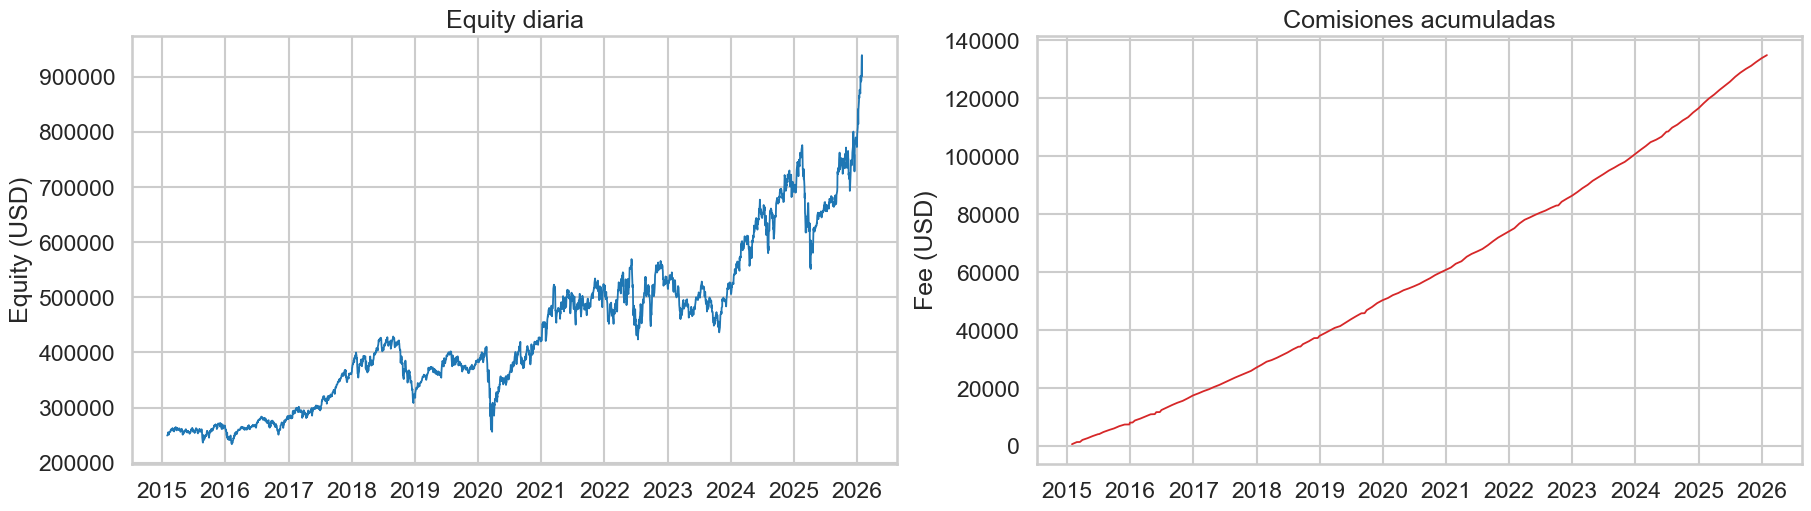

Tabla 1 - Resumen por casuistica operativa
                  case                                       regla_operativa  n_ordenes  n_meses primera_fecha ultima_fecha                                                                 evidencia_clave
          no_fill_cash          No cabe ticket entero segun sizing con OPEN.        174       90    2015-02-27   2025-12-31   Caja insuficiente real: 1/174. Resto: restriccion de acciones enteras/target.
      no_fill_at_close Gap OPEN->CLOSE hace que no alcance caja al ejecutar.         35       35    2015-02-27   2025-10-31 required_cash > cash_before en 35/35; gap mediana=136.62 USD, max=1,166.75 USD.
no_fill_non_executable      Sin precio operativo (OPEN/CLOSE no disponible).         15       13    2015-03-31   2025-05-30                             NaN decision_open=15/15, NaN execution_close=15/15.
  no_fill_open_missing       Salida de rebalanceo sin OPEN bajo strict_open.          0        0             -            -                  

In [10]:
# --- 7.2 Graficos de control principales ---
fig, axes = plt.subplots(1, 2, figsize=(18, 5), constrained_layout=True)

# Trazado de la serie sobre el eje
axes[0].plot(portfolio_daily_df["date"], portfolio_daily_df["equity"], linewidth=1.3, color="#1f77b4")
# Título descriptivo del panel
axes[0].set_title("Equity diaria")
# Etiqueta del eje
axes[0].set_ylabel("Equity (USD)")
# Configuración de propiedades del gráfico
axes[0].xaxis.set_major_locator(mdates.YearLocator())
# Configuración de propiedades del gráfico
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

if len(filled_orders) > 0:
    # Asignación de 'fee_curve'
    fee_curve = (
        filled_orders.sort_values("date")
        .groupby("date", observed=True)["fee"]
        .sum()
        # Suma acumulada para acumular flujos
        .cumsum()
        # Renombrado de columnas para claridad semántica
        .rename("cum_fee")
        # Reinicio del índice para convertir grupos en columnas regulares
        .reset_index()
    )
else:
    # Construcción del DataFrame a partir de los datos acumulados
    fee_curve = pd.DataFrame({"date": portfolio_daily_df["date"], "cum_fee": 0.0})

# Trazado de la serie sobre el eje
axes[1].plot(fee_curve["date"], fee_curve["cum_fee"], linewidth=1.3, color="#d62728")
# Título descriptivo del panel
axes[1].set_title("Comisiones acumuladas")
# Etiqueta del eje
axes[1].set_ylabel("Fee (USD)")
# Configuración de propiedades del gráfico
axes[1].xaxis.set_major_locator(mdates.YearLocator())
# Configuración de propiedades del gráfico
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Renderización del gráfico
plt.show()

# --- 7.3 Casos operativos: tablas de evidencia (sustituye 4 graficos) ---
case_order = ["no_fill_cash", "no_fill_at_close", "no_fill_non_executable", "no_fill_open_missing"]
# Asignación de 'case_rule'
case_rule = {
    "no_fill_cash": "No cabe ticket entero segun sizing con OPEN.",
    "no_fill_at_close": "Gap OPEN->CLOSE hace que no alcance caja al ejecutar.",
    "no_fill_non_executable": "Sin precio operativo (OPEN/CLOSE no disponible).",
    "no_fill_open_missing": "Salida de rebalanceo sin OPEN bajo strict_open.",
}

# Inicialización del contenedor para acumular resultados
case_rows = []
# Iteración sobre case_order
for case_name in case_order:
    # Copia defensiva (evita side-effects sobre el original)
    cdf = orders_df.loc[orders_df["status"] == case_name].copy()
    # Cómputo del tamaño: n_orders
    n_orders = int(len(cdf))
    # Conversión a período temporal para agrupación mensual/anual
    n_months = int(cdf["date"].dt.to_period("M").nunique()) if n_orders else 0
    # Valor mínimo: first_date
    first_date = cdf["date"].min().strftime("%Y-%m-%d") if n_orders else "-"
    # Valor máximo: last_date
    last_date = cdf["date"].max().strftime("%Y-%m-%d") if n_orders else "-"

    if case_name == "no_fill_cash" and n_orders:
        # Suma total: real_shortage
        real_shortage = int((cdf["required_cash_at_close"] > cdf["cash_before"]).sum())
        # Asignación de 'key_evidence'
        key_evidence = (
            f"Caja insuficiente real: {real_shortage}/{n_orders}. "
            f"Resto: restriccion de acciones enteras/target." 
        )
    elif case_name == "no_fill_at_close" and n_orders:
        # Asignación de 'key_evidence'
        key_evidence = (
            f"required_cash > cash_before en {int((cdf['required_cash_at_close'] > cdf['cash_before']).sum())}/{n_orders}; "
            # Valor máximo: f"gap mediana
            f"gap mediana={cdf['cash_gap_close'].median():,.2f} USD, max={cdf['cash_gap_close'].max():,.2f} USD."
        )
    elif case_name == "no_fill_non_executable" and n_orders:
        # Conteo de valores nulos por columna
        miss_dec = int(cdf["decision_price_open"].isna().sum())
        # Conteo de valores nulos por columna
        miss_exec = int(cdf["execution_price_close"].isna().sum())
        # Asignación de 'key_evidence'
        key_evidence = (
            f"NaN decision_open={miss_dec}/{n_orders}, NaN execution_close={miss_exec}/{n_orders}."
        )
    elif case_name == "no_fill_open_missing":
        # Asignación de 'key_evidence'
        key_evidence = "Sin ocurrencias en el periodo analizado."
    else:
        # Asignación de 'key_evidence'
        key_evidence = "-"

    # Acumulación de resultado parcial
    case_rows.append(
        {
            "case": case_name,
            "regla_operativa": case_rule[case_name],
            "n_ordenes": n_orders,
            "n_meses": n_months,
            "primera_fecha": first_date,
            "ultima_fecha": last_date,
            "evidencia_clave": key_evidence,
        }
    )

# Construcción del DataFrame a partir de los datos acumulados
cases_summary_df = pd.DataFrame(case_rows)

# Tabla de evidencia con ejemplos representativos por caso
example_rows = []

# Caso 1: un ejemplo tipico + uno de caja insuficiente real (si existe)
c1 = orders_df.loc[orders_df["status"] == "no_fill_cash"].copy()
# Evaluación condicional
if len(c1):
    # Asignación de 'c1'
    c1["real_shortage"] = c1["required_cash_at_close"] > c1["cash_before"]

    # Ordenación del DataFrame para secuencia determinista y reproducible
    typical = c1.loc[~c1["real_shortage"]].sort_values("date").head(1)
    # Iteración sobre typical.iterrows()
    for _, r in typical.iterrows():
        # Acumulación de resultado parcial
        example_rows.append(
            {
                "case": "no_fill_cash",
                "fecha": r["date"].strftime("%Y-%m-%d"),
                "symbol": r["symbol"],
                "side_reason": f"{r['side']} | {r['reason']}",
                "cash_before": float(r["cash_before"]),
                "decision_open": float(r["decision_price_open"]) if pd.notna(r["decision_price_open"]) else np.nan,
                "exec_price": float(r["execution_price_close"]) if pd.notna(r["execution_price_close"]) else np.nan,
                "required_cash": float(r["required_cash_at_close"]) if pd.notna(r["required_cash_at_close"]) else np.nan,
                "cash_gap": float(r["cash_gap_close"]) if pd.notna(r["cash_gap_close"]) else np.nan,
                "interpretacion": "No entra por restriccion de lote entero/ticket, no por falta real de caja.",
            }
        )

    # Ordenación del DataFrame para secuencia determinista y reproducible
    real = c1.loc[c1["real_shortage"]].sort_values("date").head(1)
    # Iteración sobre real.iterrows()
    for _, r in real.iterrows():
        # Acumulación de resultado parcial
        example_rows.append(
            {
                "case": "no_fill_cash",
                "fecha": r["date"].strftime("%Y-%m-%d"),
                "symbol": r["symbol"],
                "side_reason": f"{r['side']} | {r['reason']}",
                "cash_before": float(r["cash_before"]),
                "decision_open": float(r["decision_price_open"]) if pd.notna(r["decision_price_open"]) else np.nan,
                "exec_price": float(r["execution_price_close"]) if pd.notna(r["execution_price_close"]) else np.nan,
                "required_cash": float(r["required_cash_at_close"]) if pd.notna(r["required_cash_at_close"]) else np.nan,
                "cash_gap": float(r["cash_gap_close"]) if pd.notna(r["cash_gap_close"]) else np.nan,
                "interpretacion": "Falta de caja real para ejecutar 1 accion + comision minima.",
            }
        )

# Caso 2: ejemplo con mayor gap de caja al cierre
c2 = orders_df.loc[orders_df["status"] == "no_fill_at_close"].copy()
# Evaluación condicional
if len(c2):
    # Ordenación del DataFrame para secuencia determinista y reproducible
    r = c2.sort_values("cash_gap_close", ascending=False).iloc[0]
    # Acumulación de resultado parcial
    example_rows.append(
        {
            "case": "no_fill_at_close",
            "fecha": r["date"].strftime("%Y-%m-%d"),
            "symbol": r["symbol"],
            "side_reason": f"{r['side']} | {r['reason']}",
            "cash_before": float(r["cash_before"]),
            "decision_open": float(r["decision_price_open"]) if pd.notna(r["decision_price_open"]) else np.nan,
            "exec_price": float(r["execution_price_close"]) if pd.notna(r["execution_price_close"]) else np.nan,
            "required_cash": float(r["required_cash_at_close"]) if pd.notna(r["required_cash_at_close"]) else np.nan,
            "cash_gap": float(r["cash_gap_close"]) if pd.notna(r["cash_gap_close"]) else np.nan,
            "interpretacion": "Se decide con OPEN, pero CLOSE sube y el ticket final supera la caja disponible.",
        }
    )

# Caso 3: un buy y un sell representativos
c3 = orders_df.loc[orders_df["status"] == "no_fill_non_executable"].copy()
# Evaluación condicional
if len(c3):
    # Iteración sobre ["buy", "sell"]
    for side in ["buy", "sell"]:
        # Ordenación del DataFrame para secuencia determinista y reproducible
        pick = c3.loc[c3["side"] == side].sort_values("date").head(1)
        # Iteración sobre pick.iterrows()
        for _, r in pick.iterrows():
            # Acumulación de resultado parcial
            example_rows.append(
                {
                    "case": "no_fill_non_executable",
                    "fecha": r["date"].strftime("%Y-%m-%d"),
                    "symbol": r["symbol"],
                    "side_reason": f"{r['side']} | {r['reason']}",
                    "cash_before": float(r["cash_before"]),
                    "decision_open": float(r["decision_price_open"]) if pd.notna(r["decision_price_open"]) else np.nan,
                    "exec_price": float(r["execution_price_close"]) if pd.notna(r["execution_price_close"]) else np.nan,
                    "required_cash": float(r["required_cash_at_close"]) if pd.notna(r["required_cash_at_close"]) else np.nan,
                    "cash_gap": float(r["cash_gap_close"]) if pd.notna(r["cash_gap_close"]) else np.nan,
                    "interpretacion": "No hay precio ejecutable observable; orden trazada como no_fill_non_executable.",
                }
            )

# Caso 4: explicito aunque no tenga ocurrencias
c4 = orders_df.loc[orders_df["status"] == "no_fill_open_missing"].copy()
# Evaluación condicional
if len(c4) == 0:
    # Acumulación de resultado parcial
    example_rows.append(
        {
            "case": "no_fill_open_missing",
            "fecha": "-",
            "symbol": "-",
            "side_reason": "sell | rebalance_exit",
            "cash_before": np.nan,
            "decision_open": np.nan,
            "exec_price": np.nan,
            "required_cash": np.nan,
            "cash_gap": np.nan,
            "interpretacion": "Sin ocurrencias: con strict_open no se detectaron salidas sin OPEN en este backtest.",
        }
    )

# Construcción del DataFrame a partir de los datos acumulados
cases_evidence_df = pd.DataFrame(example_rows)

# Bucle iterativo sobre los elementos
for col in ["cash_before", "decision_open", "exec_price", "required_cash", "cash_gap"]:
    # Evaluación condicional
    if col in cases_evidence_df.columns:
        # Asignación de 'cases_evidence_df'
        cases_evidence_df[col] = pd.to_numeric(cases_evidence_df[col], errors="coerce").round(2)

# Salida informativa de seguimiento
print("Tabla 1 - Resumen por casuistica operativa")
# Evaluación condicional
if "display" in globals():
    # Renderización de tabla HTML para inspección del corrector
    display(cases_summary_df)
else:
    # Salida informativa de seguimiento
    print(cases_summary_df.to_string(index=False))

# Salida informativa de seguimiento
print()
# Salida informativa de seguimiento
print("Tabla 2 - Evidencia de ejemplos representativos")
# Evaluación condicional
if "display" in globals():
    # Renderización de tabla HTML para inspección del corrector
    display(cases_evidence_df)
else:
    # Salida informativa de seguimiento
    print(cases_evidence_df.to_string(index=False))


## 7.3 Interpretacion financiera, operativa y de costes

Estas tablas sustituyen los 4 graficos de no-fill y dejan evidencia auditable por caso, fecha y simbolo.

**Cumplimiento del enunciado (reglas explicitas):**

- Ventas de rebalanceo al `OPEN` del dia de rebalanceo (`rebalance_exit`, `price_type=open_rebalance`).
- Compras de entrada al `CLOSE` del mismo dia (`rebalance_entry`, `price_type=close_rebalance`).
- Comision aplicada por orden ejecutada: `max(0.23% * nocional, 23 USD)`.
- Cuando un activo sale del indice/mercado, se liquida en salida forzosa y el efectivo queda en caja hasta siguiente rebalanceo.

**Interpretacion de las casuisticas:**

- `no_fill_cash`: el sizing en acciones enteras no permite ejecutar el ticket bajo la politica de caja. En la mayoria de casos no es falta de caja total, sino efecto de granularidad (accion entera + fee minima) y del orden secuencial de compras.
- `no_fill_at_close`: la orden se dimensiona con referencia `OPEN`, pero el `CLOSE` definitivo exige mas efectivo (`required_cash_at_close > cash_before`) y se rechaza sin redimensionar al cierre para evitar look-ahead intradia.
- `no_fill_non_executable`: falta precio operativo (OPEN/CLOSE valido) y la orden no se inventa; se registra como no ejecutable para trazabilidad.
- `no_fill_open_missing`: con politica `strict_open`, si faltara OPEN en una salida de rebalanceo se registraria no-fill en lugar de usar precio sintetico. En este backtest concreto no hubo ocurrencias.

**Supuestos de implementacion en zonas no detalladas por el enunciado:**

- Politica de cartera incompleta: `cash_only`. Si no se alcanzan 20 posiciones por fricciones de ejecucion, el remanente se mantiene en liquidez.
- Acciones fraccionales: no permitidas. El motor opera con acciones enteras para todas las compras/ventas.
- Faltante de precio en salida forzosa no cubierta por la regla de rebalanceo: se usa `last_seen_close` como proxy (`forced_exit_no_quote_proxy`) para no romper continuidad contable, dejando fecha de proxy en el log.

Con esto, la evidencia operativa queda alineada con el enunciado, y las excepciones quedan documentadas de forma reproducible y auditable en `n4_orders_log.csv`.

In [11]:
# --- 7.4 Resumen final ejecutivo ---
underfilled_months_df = rebalance_operational_summary_df.loc[
    rebalance_operational_summary_df["n_positions_end"] < TOP_N,
    [
        "date",
        "n_target",
        "n_entries_filled",
        "n_no_fill_cash",
        "n_no_fill_at_close",
        "n_no_fill_non_executable",
        "n_no_fill_open_missing",
        "n_positions_end",
        "cash_end",
    ],
].copy()

# Cómputo del tamaño: n_underfilled
n_underfilled = int(len(underfilled_months_df))
# Cómputo del tamaño: n_no_fill_cash
n_no_fill_cash = int((orders_df["status"] == "no_fill_cash").sum()) if len(orders_df) else 0
# Cómputo del tamaño: n_no_fill_at_close
n_no_fill_at_close = int((orders_df["status"] == "no_fill_at_close").sum()) if len(orders_df) else 0
# Cómputo del tamaño: n_no_fill_open_missing
n_no_fill_open_missing = int((orders_df["status"] == "no_fill_open_missing").sum()) if len(orders_df) else 0
# Conversión a entero: n_proxy_forced
n_proxy_forced = int(
    orders_df.loc[
        (orders_df["reason"] == "forced_exit_no_quote_proxy") & (orders_df["status"] == "filled")
    ].shape[0]
) if len(orders_df) else 0

# Salida informativa de seguimiento
print()
# Separador visual del bloque de resumen
print("=" * 64)
# Salida informativa de seguimiento
print("  NOTEBOOK 4 - RESUMEN FINAL")
# Separador visual del bloque de resumen
print("=" * 64)
# Diagnóstico con trazabilidad del resultado
print(f"  Controles criticos: {n_pass}/{n_crit} PASS")
# Diagnóstico con trazabilidad del resultado
print(f"  Politica OPEN faltante: {EXIT_WITHOUT_OPEN_POLICY}")
# Diagnóstico con trazabilidad del resultado
print(f"  Politica cartera incompleta: {UNDERFILLED_PORTFOLIO_POLICY}")
# Diagnóstico con trazabilidad del resultado
print(f"  Capital inicial: ${initial_capital:,.0f}")
# Diagnóstico con trazabilidad del resultado
print(f"  Equity final: ${cost_summary_df['final_equity'].iloc[0]:,.2f}")
# Diagnóstico con trazabilidad del resultado
print(f"  Return vs capital inicial: {cost_summary_df['return_vs_initial_capital'].iloc[0]:.2%}")
# Diagnóstico con trazabilidad del resultado
print(f"  Return desde valoracion 1: {cost_summary_df['return_from_first_valuation'].iloc[0]:.2%}")
# Diagnóstico con trazabilidad del resultado
print(f"  Comisiones totales: ${cost_summary_df['total_fee'].iloc[0]:,.2f}")
# Diagnóstico con trazabilidad del resultado
print(f"  Ordenes filled: {int(cost_summary_df['n_filled_orders'].iloc[0]):,}")
# Diagnóstico con trazabilidad del resultado
print(f"  No-fill por caja: {n_no_fill_cash}")
# Diagnóstico con trazabilidad del resultado
print(f"  No-fill al cierre: {n_no_fill_at_close}")
# Diagnóstico con trazabilidad del resultado
print(f"  No-fill por OPEN faltante: {n_no_fill_open_missing}")
# Diagnóstico con trazabilidad del resultado
print(f"  Proxy forced exits: {n_proxy_forced}")
# Diagnóstico con trazabilidad del resultado
print(f"  Meses con <{TOP_N} posiciones: {n_underfilled}")
# Separador visual del bloque de resumen
print("=" * 64)
if n_pass == n_crit:
    # Salida informativa de seguimiento
    print("  STATUS: PASS - Pipeline listo para Notebook 5.")
else:
    # Salida informativa de seguimiento
    print("  STATUS: FAIL - Revisar controles fallidos.")
# Separador visual del bloque de resumen
print("=" * 64)

if n_underfilled > 0:
    # Salida informativa de seguimiento
    print("Primeras fechas con cartera incompleta:")
    if "display" in globals():
        # Renderización de tabla HTML para inspección del corrector
        display(underfilled_months_df.head(10))
    else:
        # Salida informativa de seguimiento
        print(underfilled_months_df.head(10).to_string(index=False))




  NOTEBOOK 4 - RESUMEN FINAL
  Controles criticos: 36/36 PASS
  Politica OPEN faltante: strict_open
  Politica cartera incompleta: cash_only
  Capital inicial: $250,000
  Equity final: $901,325.73
  Return vs capital inicial: 260.53%
  Return desde valoracion 1: 261.35%
  Comisiones totales: $134,828.27
  Ordenes filled: 3,594
  No-fill por caja: 174
  No-fill al cierre: 35
  No-fill por OPEN faltante: 0
  Proxy forced exits: 16
  Meses con <20 posiciones: 47
  STATUS: PASS - Pipeline listo para Notebook 5.
Primeras fechas con cartera incompleta:
      date  n_target  n_entries_filled  n_no_fill_cash  n_no_fill_at_close  n_no_fill_non_executable  n_no_fill_open_missing  n_positions_end     cash_end
2015-02-27        20                14               4                   1                         0                       0               19 12368.546867
2015-03-31        20                14               2                   0                         1                       0            